In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN, AgglomerativeClustering
from scipy.spatial import cKDTree

class UniversalCascadeTracer:
    def __init__(self, raw_df, smoothing_window=5, min_cluster_sizes=[15, 10, 5, 3]):
        # raw_df 包含所有天數的資料
        self.raw_df = raw_df.sort_values(['uid', 'd', 't']).reset_index(drop=True)
        self.smoothing_window = smoothing_window
        self.mcs_list = min_cluster_sizes
        
        self.global_hubs = {} # {g_id: (x, y)}
        self.user_local_hubs = {} # {uid: {l_id: (x, y)}}
        self.event_log = pd.DataFrame()

    def _cluster_logic(self, coords, merge_dist=8.0):
        """復用你的 Adaptive HDBSCAN 邏輯"""
        best_labels = None
        for mcs in self.mcs_list:
            db = HDBSCAN(min_cluster_size=mcs).fit(coords)
            unique_zones = set(db.labels_) - {-1}
            best_labels = db.labels_
            if len(unique_zones) > 1: break
                
        temp_df = pd.DataFrame(coords, columns=['x', 'y'])
        temp_df['zone_id'] = best_labels
        
        temp_c = temp_df[temp_df['zone_id'] != -1].groupby('zone_id')[['x', 'y']].mean()
        if len(temp_c) >= 2:
            agg = AgglomerativeClustering(n_clusters=None, distance_threshold=merge_dist, linkage='single')
            mapping = dict(zip(temp_c.index, agg.fit_predict(temp_c)))
            temp_df['zone_id'] = temp_df['zone_id'].map(lambda x: mapping.get(x, -1))
            
        centroids = temp_df[temp_df['zone_id'] != -1].groupby('zone_id')[['x', 'y']].mean().to_dict('index')
        return temp_df['zone_id'].values, centroids

    # ==========================================
    # PHASE 1: OFFLINE BUILD (全域建置)
    # ==========================================
    def build_universal_hubs_and_log(self, radius_K):
        print("1. 針對所有使用者萃取 Local Hubs (跨天)...")
        all_local_centroids = []
        hub_events = []
        
        for uid, user_df in self.raw_df.groupby('uid'):
            # 跨天平滑化與分群
            smooth_x = user_df['x'].rolling(window=self.smoothing_window, center=True, min_periods=1).median()
            smooth_y = user_df['y'].rolling(window=self.smoothing_window, center=True, min_periods=1).median()
            coords = np.column_stack((smooth_x, smooth_y))
            
            labels, centroids = self._cluster_logic(coords)
            
            self.user_local_hubs[uid] = {}
            for l_id, center in centroids.items():
                coord = (center['x'], center['y'])
                self.user_local_hubs[uid][l_id] = coord
                all_local_centroids.append({'uid': uid, 'l_id': l_id, 'x': coord[0], 'y': coord[1]})
            
            # 暫存 Event Log (此時還沒有 Global ID)
            user_df_copy = user_df.copy()
            user_df_copy['local_hub'] = labels
            valid_events = user_df_copy[user_df_copy['local_hub'] != -1]
            
            for _, row in valid_events.iterrows():
                hub_events.append({
                    'uid': uid, 'd': row['d'], 't': row['t'],
                    'local_hub': row['local_hub']
                })

        print("2. 聚合 Local Centroids 建立 Global Hubs...")
        # 將所有 Local Hubs 當作點，再跑一次分群產生 Global Hubs (大幅降維，效能極高)
        centroid_df = pd.DataFrame(all_local_centroids)
        global_labels, global_centroids = self._cluster_logic(centroid_df[['x', 'y']].values, merge_dist=radius_K)
        centroid_df['global_hub'] = global_labels
        
        self.global_hubs = {g_id: (val['x'], val['y']) for g_id, val in global_centroids.items()}
        
        print("3. 建立 Universal Event Log...")
        # 將 Global Hub 映射回 Event Log
        mapping_dict = centroid_df.set_index(['uid', 'l_id'])['global_hub'].to_dict()
        
        self.event_log = pd.DataFrame(hub_events)
        self.event_log['global_hub'] = self.event_log.apply(
            lambda x: mapping_dict.get((x['uid'], x['local_hub']), -1), axis=1
        )
        print("Universal Hubs 與 Event Log 建置完成！")

    # ==========================================
    # PHASE 2: ONLINE QUERY (單日查詢)
    # ==========================================
    def trace_cascade_by_day(self, target_d, target_t_range, target_global_hub):
        """
        利用建好的全域 Event Log，以極低的計算成本進行單日連鎖追蹤
        """
        # 1. 僅切出當天資料
        day_events = self.event_log[self.event_log['d'] == target_d]
        if day_events.empty:
            return {}, {}
            
        t_start, t_end = target_t_range
        
        # 2. 尋找 Primary Impact (當天、該時段、造訪該 Global Hub 的人)
        primary_hits = day_events[
            (day_events['t'] >= t_start) & 
            (day_events['t'] <= t_end) & 
            (day_events['global_hub'] == target_global_hub)
        ]
        
        # 紀錄最早感染時間 t_exp
        primary_info = primary_hits.groupby('uid')['t'].min().to_dict()
        primary_uids = set(primary_info.keys())
        
        # 3. 尋找 Secondary Impact
        secondary_info = {}
        for p_uid, t_exp in primary_info.items():
            # Primary User 感染後的活動
            p_after = day_events[(day_events['uid'] == p_uid) & (day_events['t'] > t_exp)]
            
            for _, row in p_after.iterrows():
                hub_t = row['t']
                p_global_hub = row['global_hub']
                
                # 若無對齊到 Global Hub (Noise)，忽略
                if p_global_hub == -1: continue 
                
                # 尋找同時間，也在同一個 Global Hub 的其他人
                sync_events = day_events[
                    (day_events['t'] == hub_t) & 
                    (day_events['global_hub'] == p_global_hub) & 
                    (day_events['uid'] != p_uid)
                ]
                
                for s_uid in sync_events['uid'].unique():
                    if s_uid not in primary_uids:
                        if s_uid not in secondary_info or secondary_info[s_uid] > hub_t:
                            secondary_info[s_uid] = hub_t
                            
        return primary_info, secondary_info
def plot_global_hubs_topology(tracer):
    """
    視覺化 1: 純粹顯示所有的 Global Hubs 分布
    """
    plt.figure(figsize=(10, 8))
    
    # 提取 Global Hubs 座標
    if not tracer.global_hubs:
        print("沒有找到 Global Hubs，請確認是否已執行 build_universal_hubs_and_log")
        return
        
    g_x = [coord[0] for coord in tracer.global_hubs.values()]
    g_y = [coord[1] for coord in tracer.global_hubs.values()]
    g_ids = list(tracer.global_hubs.keys())
    
    # 繪製 Global Hubs
    plt.scatter(g_x, g_y, c='red', marker='*', s=200, edgecolor='black', zorder=5, label='Global Hubs')
    
    # 加上 ID 標籤以便識別
    for i, txt in enumerate(g_ids):
        plt.annotate(f"G{txt}", (g_x[i], g_y[i]), xytext=(5, 5), textcoords='offset points', fontsize=9, color='darkred')
        
    plt.title('Global Hubs Topology', weight='bold', fontsize=14)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

def plot_user_hubs_alignment(tracer, target_uid, radius_K):
    """
    視覺化 2: 顯示特定使用者的 Local Hubs，以及它們如何對齊到 Global Hubs
    """
    plt.figure(figsize=(12, 10))
    
    # 1. 畫出所有的 Global Hubs (當作半透明背景)
    g_x = [coord[0] for coord in tracer.global_hubs.values()]
    g_y = [coord[1] for coord in tracer.global_hubs.values()]
    plt.scatter(g_x, g_y, c='lightgray', marker='*', s=150, zorder=1, label='Other Global Hubs')
    
    # 畫出 Global Hubs 的 Radius K 範圍 (幫助視覺判定為什麼會吸附)
    ax = plt.gca()
    for gx, gy in zip(g_x, g_y):
        circle = plt.Circle((gx, gy), radius_K, color='gray', fill=False, linestyle=':', alpha=0.3)
        ax.add_patch(circle)

    # 2. 獲取該 User 的 Local Hubs
    user_local_hubs = tracer.user_local_hubs.get(target_uid, {})
    if not user_local_hubs:
        print(f"User {target_uid} 沒有 Local Hubs。")
        return
        
    # 3. 從 Event Log 找出對齊關係 (Mapping)
    user_events = tracer.event_log[tracer.event_log['uid'] == target_uid]
    mapping = user_events[['local_hub', 'global_hub']].drop_duplicates().set_index('local_hub')['global_hub'].to_dict()

    # 4. 畫出 Local Hubs 並連線到 Global Hubs
    for l_id, l_coord in user_local_hubs.items():
        g_id = mapping.get(l_id, -1)
        
        # 畫出 Local Hub (藍色方塊)
        plt.scatter(l_coord[0], l_coord[1], c='dodgerblue', marker='s', s=80, edgecolor='black', zorder=4)
        plt.annotate(f"L{l_id}", (l_coord[0], l_coord[1]), xytext=(-15, 5), textcoords='offset points', fontsize=9, color='blue')
        
        if g_id != -1 and g_id in tracer.global_hubs:
            g_coord = tracer.global_hubs[g_id]
            # 畫出目標 Global Hub (突顯為紅色星星)
            plt.scatter(g_coord[0], g_coord[1], c='red', marker='*', s=200, edgecolor='black', zorder=5)
            # 畫出吸附虛線
            plt.plot([l_coord[0], g_coord[0]], [l_coord[1], g_coord[1]], color='red', linestyle='--', linewidth=1.5, zorder=3, alpha=0.7)
        else:
            # 沒有對齊到 Global Hub (視為純 Local/Noise)
            plt.scatter(l_coord[0], l_coord[1], c='orange', marker='s', s=80, edgecolor='black', zorder=4)

    # 圖例設定
    custom_lines = [
        mlines.Line2D([0], [0], color='w', marker='*', markerfacecolor='red', markersize=15, markeredgecolor='k'),
        mlines.Line2D([0], [0], color='w', marker='s', markerfacecolor='dodgerblue', markersize=10, markeredgecolor='k'),
        mlines.Line2D([0], [0], color='w', marker='s', markerfacecolor='orange', markersize=10, markeredgecolor='k'),
        mlines.Line2D([0], [0], color='red', linestyle='--', lw=1.5)
    ]
    plt.legend(custom_lines, [
        'Matched Global Hub', 
        'Local Hub (Matched)', 
        'Local Hub (Unmatched / Isolated)',
        'Alignment Vector (Snap)'
    ])
    
    plt.title(f'Hub Alignment View for User: {target_uid}', weight='bold', fontsize=14)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True, linestyle='-', alpha=0.3)
    plt.axis('equal') # 確保 X Y 軸比例一致，這樣半徑 K 的圓形才不會變形
    plt.show()

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 0. 讀取資料
# ==========================================
print("Loading data...")
df = pd.read_parquet('./data/cityA-dataset.parquet')
# 抽樣前 1000 位使用者進行全域 Hub 測試
select_df = df[df['uid'].isin(range(1000))].copy()
select_df = select_df.dropna(subset=['x', 'y', 'd', 't'])

# ==========================================
# 1. 初始化系統與全域建置 (Offline Build)
# ==========================================
# 這裡使用上一輪設計的 UniversalCascadeTracer




Loading data...
1. 針對所有使用者萃取 Local Hubs (跨天)...
2. 聚合 Local Centroids 建立 Global Hubs...
3. 建立 Universal Event Log...
Universal Hubs 與 Event Log 建置完成！



Tracing cascade for Target Global Hub: G23 on Day 2
----------------------------------------
📊 [Cascading Impact Statistics]
----------------------------------------
1. Target Global Hub ID: G23
2. Primary Impacted Users: 39
3. Secondary Impacted Users: 112
4. Total Global Hubs (All-time): 32
5. Active Global Hubs (Day 2): 32
6. Avg Local Hubs per User (Day 2): 1.62 (Max: 7, Min: 1)
7. Hubs visited by Primary Users (Post-exposure): 61
8. Hubs visited by Secondary Users (Post-exposure): 182
----------------------------------------


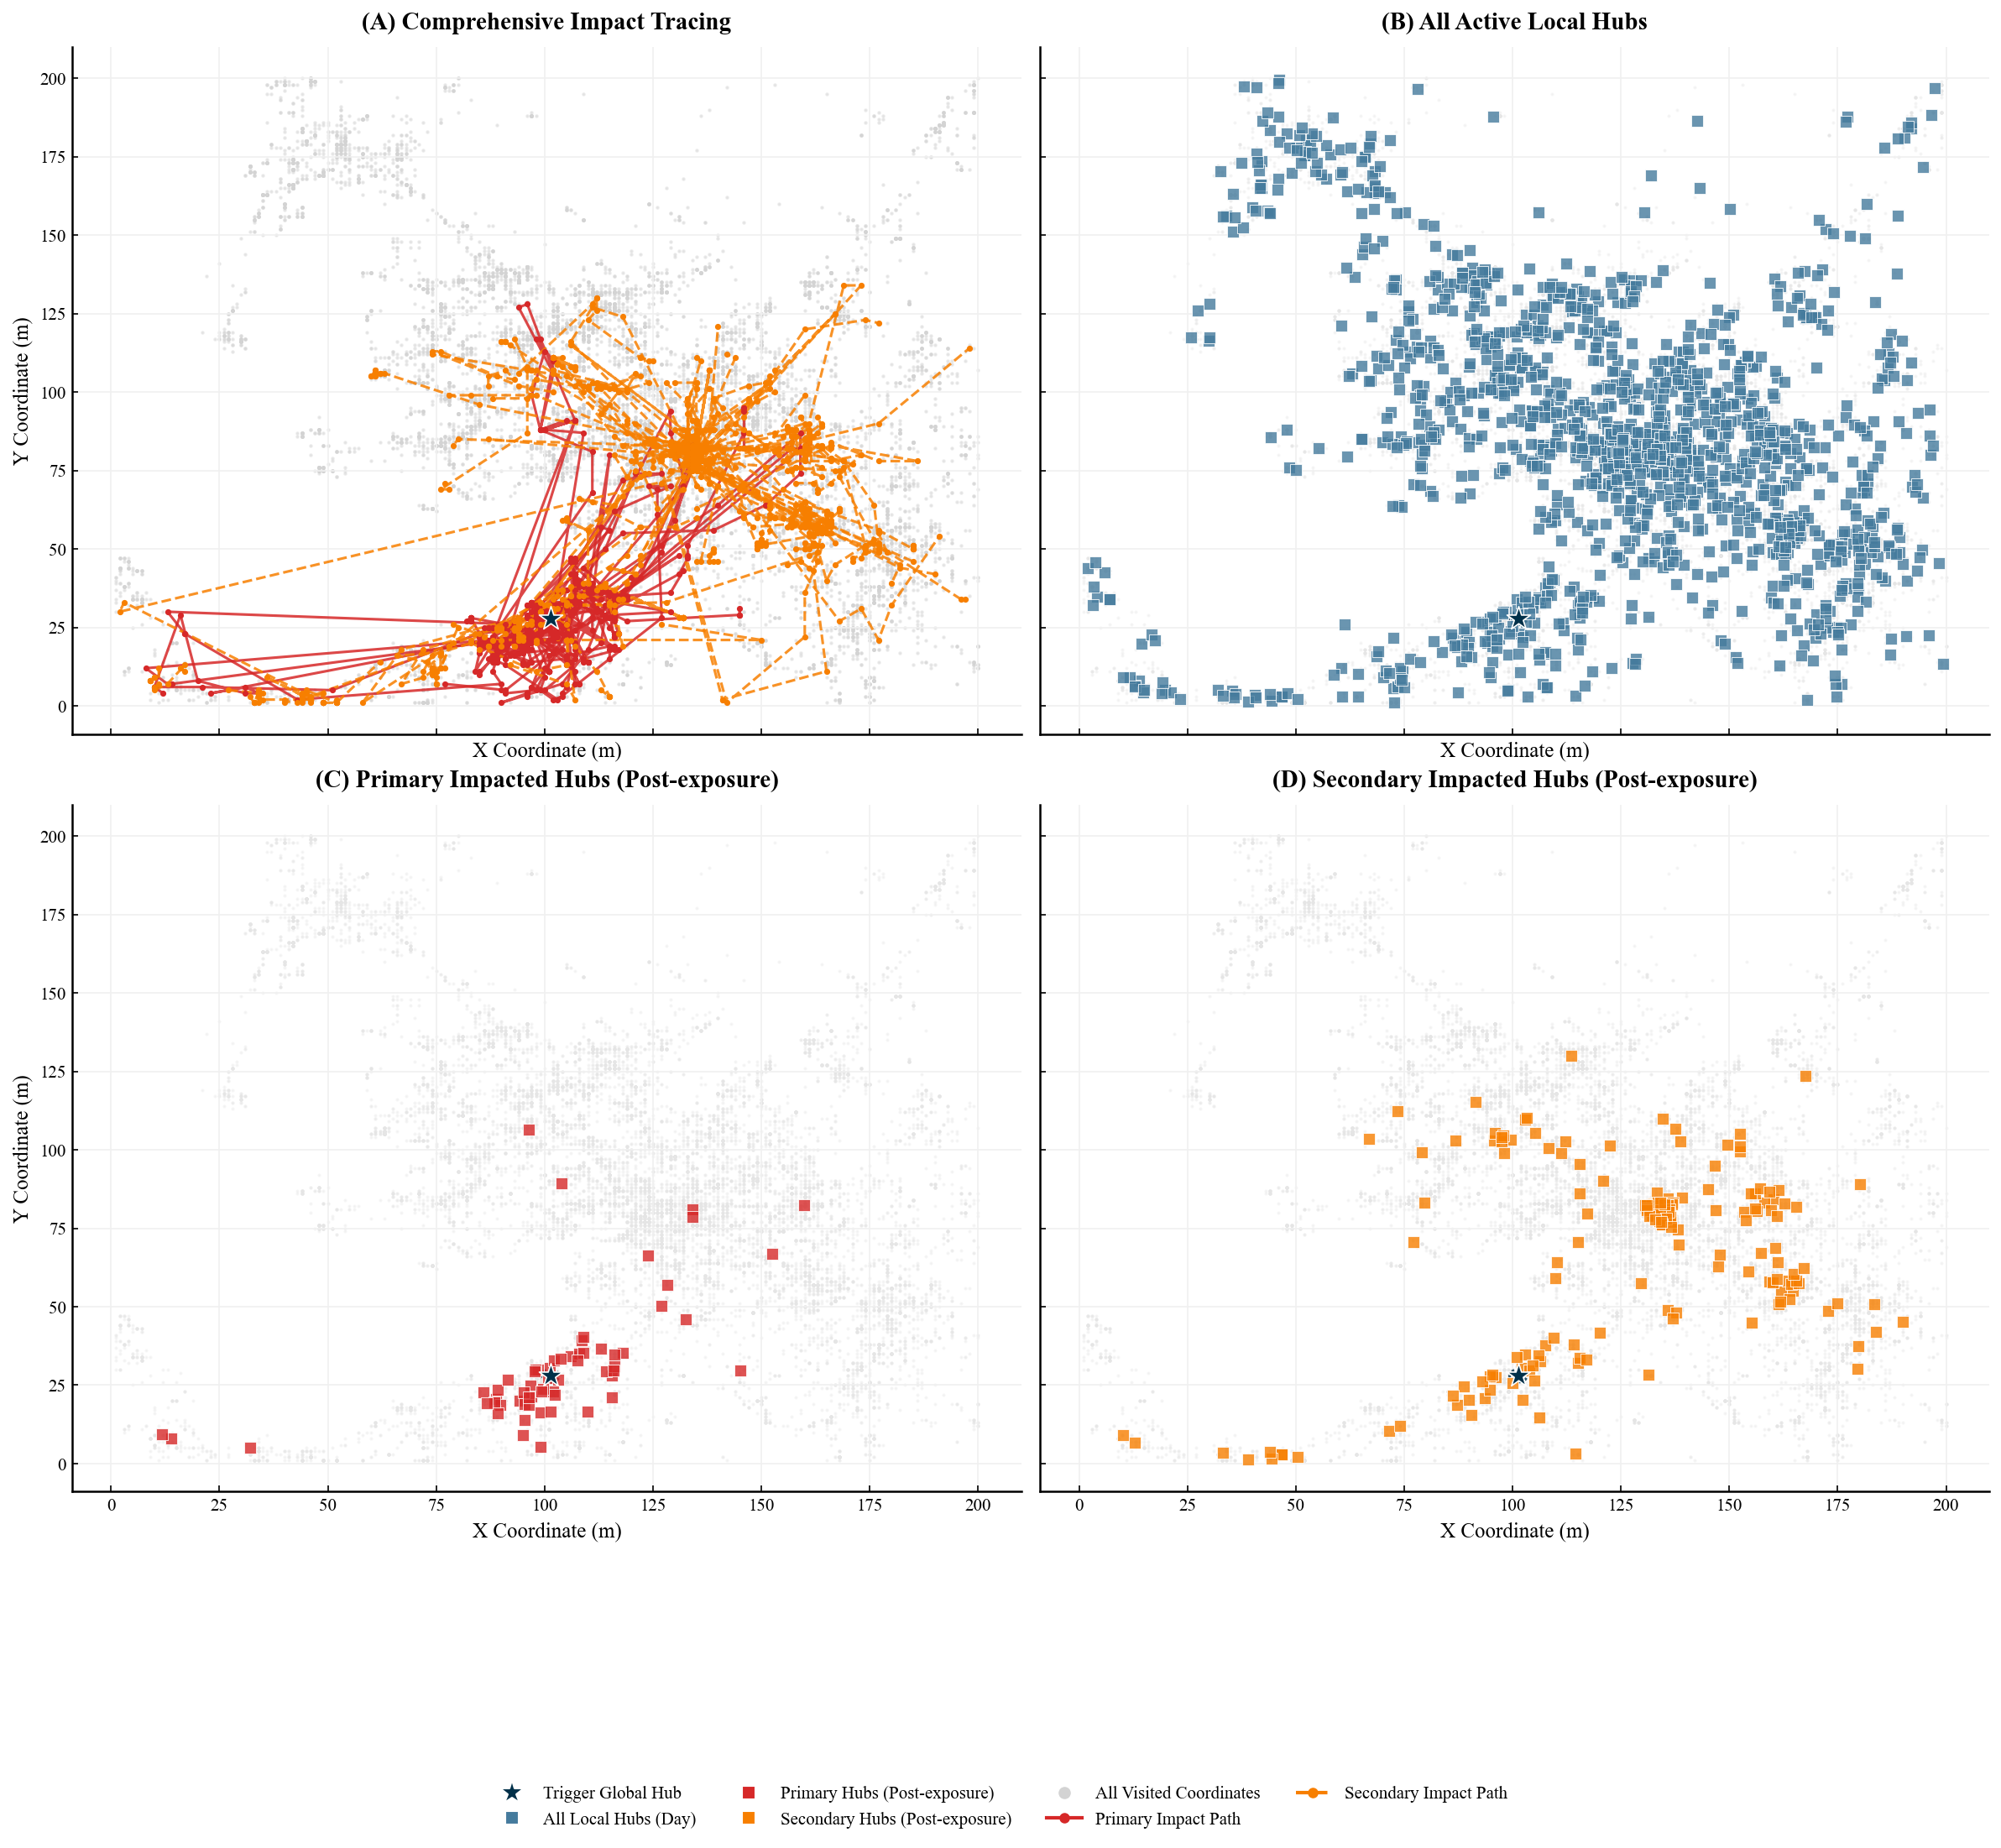

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# ACADEMIC FORMATTING SETTINGS (Strict)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'


def plot_comprehensive_academic_cascade(tracer, target_d, primary_info, secondary_info, target_global_hub, radius_K):
    """
    产生一个 2x2 的学術版綜合連鎖傳播追蹤圖。
    """
    # ==========================================
    # 資料準備
    # ==========================================
    day_events = tracer.event_log[tracer.event_log['d'] == target_d]
    day_raw_df = tracer.raw_df[tracer.raw_df['d'] == target_d]

    # 提取當天所有的 Local Hubs 座標
    all_day_hubs_coords = []
    for _, row in day_events.drop_duplicates(subset=['uid', 'local_hub']).iterrows():
        coord = tracer.user_local_hubs[row['uid']][row['local_hub']]
        all_day_hubs_coords.append(coord)

    # 提取 Primary Hubs 座標 (被感染後的停留點)
    primary_hubs_coords = []
    for uid, t_exp in primary_info.items():
        user_after_exp = day_events[(day_events['uid'] == uid) & (day_events['t'] >= t_exp)]
        for l_hub in user_after_exp['local_hub'].unique():
            primary_hubs_coords.append(tracer.user_local_hubs[uid][l_hub])

    # 提取 Secondary Hubs 座標 (被感染後的停留點)
    secondary_hubs_coords = []
    for uid, t_exp in secondary_info.items():
        user_after_exp = day_events[(day_events['uid'] == uid) & (day_events['t'] >= t_exp)]
        for l_hub in user_after_exp['local_hub'].unique():
            secondary_hubs_coords.append(tracer.user_local_hubs[uid][l_hub])

    g_coord = tracer.global_hubs[target_global_hub]

    # ==========================================
    # (4) 計算統計數據 (保持不變)
    # ==========================================
    print("-" * 40)
    print("📊 [Cascading Impact Statistics]")
    print("-" * 40)
    print(f"1. Target Global Hub ID: G{target_global_hub}")
    print(f"2. Primary Impacted Users: {len(primary_info)}")
    print(f"3. Secondary Impacted Users: {len(secondary_info)}")

    # 計算 Hub Counts
    total_global_hubs_all_time = len(tracer.global_hubs)
    active_global_hubs_today = day_events['global_hub'].replace(-1, pd.NA).dropna().nunique()
    print(f"4. Total Global Hubs (All-time): {total_global_hubs_all_time}")
    print(f"5. Active Global Hubs (Day {target_d}): {active_global_hubs_today}")

    # 計算每個 User 當天的平均 Hub 數量
    hubs_per_user = day_events.groupby('uid')['local_hub'].nunique()
    print(
        f"6. Avg Local Hubs per User (Day {target_d}): {hubs_per_user.mean():.2f} (Max: {hubs_per_user.max()}, Min: {hubs_per_user.min()})")

    # 統計 Primary / Secondary 產生的 Hubs 數量
    print(f"7. Hubs visited by Primary Users (Post-exposure): {len(set(primary_hubs_coords))}")
    print(f"8. Hubs visited by Secondary Users (Post-exposure): {len(set(secondary_hubs_coords))}")
    print("-" * 40)

    # ==========================================
    # 繪圖 (2x2 Subplots)
    # ==========================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharex=True, sharey=True, dpi=150)

    # 共用設定
    hub_colors = ['#457B9D', '#D62828', '#F77F00']  # 藍、深紅、橘黃
    global_hub_color = '#003049'
    background_trajectory_color = '#E5E5E5'

    # --- Panel 1: Comprehensive Tracing ---
    ax1 = axes[0, 0]
    # Background
    ax1.scatter(day_raw_df['x'], day_raw_df['y'],
               c='#D3D3D3', s=1.5, alpha=0.4, zorder=1)

    # Primary Impact Tracing (紅色實線)
    for uid, t_exp in primary_info.items():
        user_traj = day_raw_df[day_raw_df['uid'] == uid].sort_values('t')
        ax1.plot(user_traj['x'], user_traj['y'],
                color='#D62828', linewidth=1.5, alpha=0.85, zorder=3)
        ax1.scatter(user_traj['x'], user_traj['y'],
                   color='#D62828', s=6, zorder=4)

    # Secondary Impact Tracing (橘黃色虛線，僅畫出受感染後的情境)
    for uid, t_exp in secondary_info.items():
        # 篩選出大於等於感染時間 (t_exp) 的軌跡
        user_traj = day_raw_df[(day_raw_df['uid'] == uid) & (day_raw_df['t'] >= t_exp)].sort_values('t')
        ax1.plot(user_traj['x'], user_traj['y'],
                color='#F77F00', linewidth=1.5, alpha=0.85, linestyle='--', zorder=3)
        ax1.scatter(user_traj['x'], user_traj['y'],
                   color='#F77F00', s=6, zorder=4)

    ax1.set_title('(A) Comprehensive Impact Tracing', weight='bold', pad=10)

    # --- Panel 2: All Active Local Hubs ---
    ax2 = axes[0, 1]
    # Background Trajectories
    ax2.scatter(day_raw_df['x'], day_raw_df['y'], c=background_trajectory_color, s=1, alpha=0.3, zorder=1)
    # Hubs
    if all_day_hubs_coords:
        hx, hy = zip(*all_day_hubs_coords)
        ax2.scatter(hx, hy, c=hub_colors[0], marker='s', s=40, edgecolor='white', linewidth=0.5, zorder=4, alpha=0.8)
    ax2.set_title('(B) All Active Local Hubs', weight='bold', pad=10)

    # --- Panel 3: Primary Impacted Hubs ---
    ax3 = axes[1, 0]
    # Background Trajectories
    ax3.scatter(day_raw_df['x'], day_raw_df['y'], c=background_trajectory_color, s=1, alpha=0.3, zorder=1)
    # Hubs
    if primary_hubs_coords:
        hx, hy = zip(*primary_hubs_coords)
        ax3.scatter(hx, hy, c=hub_colors[1], marker='s', s=40, edgecolor='white', linewidth=0.5, zorder=4, alpha=0.8)
    ax3.set_title('(C) Primary Impacted Hubs (Post-exposure)', weight='bold', pad=10)

    # --- Panel 4: Secondary Impacted Hubs ---
    ax4 = axes[1, 1]
    # Background Trajectories
    ax4.scatter(day_raw_df['x'], day_raw_df['y'], c=background_trajectory_color, s=1, alpha=0.3, zorder=1)
    # Hubs
    if secondary_hubs_coords:
        hx, hy = zip(*secondary_hubs_coords)
        ax4.scatter(hx, hy, c=hub_colors[2], marker='s', s=40, edgecolor='white', linewidth=0.5, zorder=4, alpha=0.8)
    ax4.set_title('(D) Secondary Impacted Hubs (Post-exposure)', weight='bold', pad=10)

    # --- Common Styling for All Axes ---
    for i, ax in enumerate(axes.flat):
        # 畫出 Global Hub Trigger 範圍 (所有圖表共用)
        circle = plt.Circle(g_coord, radius_K, color=global_hub_color, fill=False, linestyle=':', linewidth=1.5, zorder=2,
                            alpha=0.8)
        ax.add_patch(circle)
        ax.scatter(g_coord[0], g_coord[1], c=global_hub_color, marker='*', s=200, edgecolor='white', linewidth=0.8,
                   zorder=5)

        ax.set_xlabel('X Coordinate (m)')
        if i % 2 == 0:  # 左側子圖設定 Y 軸標籤
            ax.set_ylabel('Y Coordinate (m)')

        # 美化邊框
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle='-', color='#F0F0F0', zorder=0)

    # ==========================================
    # 自訂全局圖例 (Legend)
    # ==========================================
    custom_lines = [
        mlines.Line2D([0], [0], color='w', marker='*', markerfacecolor=global_hub_color, markeredgecolor='white',
                      markersize=14),
        mlines.Line2D([0], [0], color='w', marker='s', markerfacecolor=hub_colors[0], markeredgecolor='white',
                      markersize=8),
        mlines.Line2D([0], [0], color='w', marker='s', markerfacecolor=hub_colors[1], markeredgecolor='white',
                      markersize=8),
        mlines.Line2D([0], [0], color='w', marker='s', markerfacecolor=hub_colors[2], markeredgecolor='white',
                      markersize=8),
        mlines.Line2D([0], [0], color='w', marker='o', markerfacecolor='#D3D3D3', markersize=8),
        mlines.Line2D([0], [0], color='#D62828', lw=2, marker='o', markersize=5),
        mlines.Line2D([0], [0], color='#F77F00', lw=2, linestyle='--', marker='o', markersize=5)
    ]
    fig.legend(custom_lines, [
        'Trigger Global Hub',
        'All Local Hubs (Day)',
        'Primary Hubs (Post-exposure)',
        'Secondary Hubs (Post-exposure)',
        'All Visited Coordinates',
        'Primary Impact Path',
        'Secondary Impact Path'
    ], loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=False)

    plt.tight_layout()
    # 預留底部空間給圖例
    plt.subplots_adjust(bottom=0.15)
    plt.show()


# ==========================================
# 呼叫腳本 (Calling Script)
# ==========================================

tracer = UniversalCascadeTracer(select_df, smoothing_window=5, min_cluster_sizes=[15, 10, 5, 3])
RADIUS_K = 2.0

TARGET_DAY =  2
tracer.build_universal_hubs_and_log(radius_K=RADIUS_K)
TIME_WINDOW = (12, 18)

# 執行全域 Hub 與 Universal Event Log 建置
# 2. 自動尋找當天最熱門的 Global Hub 進行測試 (避開 -1 雜訊)
day_events = tracer.event_log[tracer.event_log['d'] == TARGET_DAY]
valid_global_hubs = day_events[day_events['global_hub'] != -1]['global_hub'].dropna()

if not valid_global_hubs.empty:
    target_global_hub = valid_global_hubs.value_counts().index[0]
    print(f"\nTracing cascade for Target Global Hub: G{target_global_hub} on Day {TARGET_DAY}")

    # 3. 執行追蹤邏輯
    primary_info, secondary_info = tracer.trace_cascade_by_day(
        target_d=TARGET_DAY,
        target_t_range=TIME_WINDOW,
        target_global_hub=target_global_hub
    )

    # 4. 執行綜合分析、統計印出與繪製 2x2 圖表
    if len(primary_info) > 0:
        plot_comprehensive_academic_cascade(
            tracer=tracer,
            target_d=TARGET_DAY,
            primary_info=primary_info,
            secondary_info=secondary_info,
            target_global_hub=target_global_hub,
            radius_K=RADIUS_K
        )
    else:
        print("未發現足跡重疊，無法繪圖。")
else:
    print(f"Day {TARGET_DAY} 沒有足夠的 Hub 資料。")